In [1]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dotenv import load_dotenv
import datetime
import os
import mplfinance as mpf
import re
import utils

In [2]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [3]:
start_time='08:30:00'
end_time='09:30:00'

In [4]:
query_min = "SELECT * FROM gold.active_1min WHERE bar_time BETWEEN %(start)s AND %(end)s ORDER BY bar_date, bar_time"
df_min = pd.read_sql(query_min,engine, params={"start": start_time, "end": end_time})

Volume Analysis

count    13908.000000
mean      4527.932097
std       2410.428296
min       1274.070000
25%       2793.000000
50%       3940.500000
75%       5639.250000
max      13288.670000
Name: volume_winsorized, dtype: float64

Median:  3940.5
Std Dev:  2410.4282956095713
IQR:  2846.25


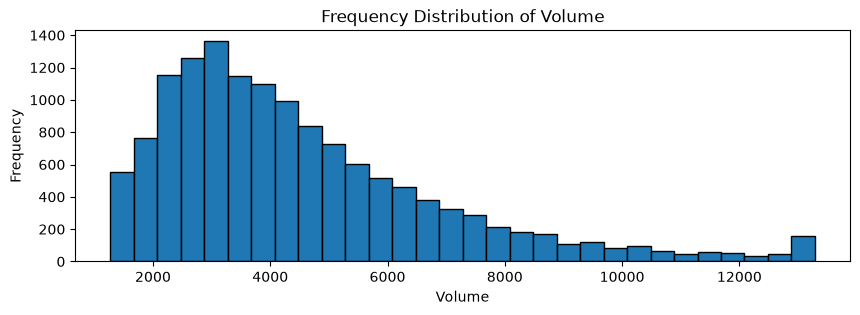

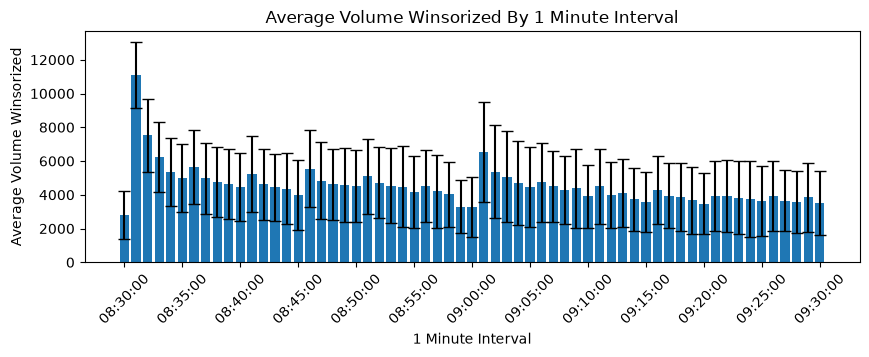

In [11]:
df_min = utils.add_winsorized_col(df_min,'volume')
volume_agg_win = utils.descriptive_groupby(df_min,'bar_time','volume_winsorized')
xlabel_bins = 16
hist_bins = 30

utils.descriptive_analysis(df_min,'volume_winsorized')
utils.frequency_hist(df_min,'volume_winsorized',hist_bins,'Volume')
utils.bar_chart(volume_agg_win,'mean','1 Minute Interval', 'Average Volume Winsorized',tickbin=xlabel_bins,yerror=volume_agg['std'])

Swing Analysis By Time

In [12]:
df_swings= utils.get_swings(df_min)
df_swings['profit'] = np.where(
    df_swings['trend']=='UP', 
    abs(df_swings['open']-df_swings['high']), 
    abs(df_swings['open']-df_swings['low'])
)
df_swings = utils.add_winsorized_col(df_swings,'profit')

In [17]:
def analyze_swings_by_time(df,bucket,timeframe,target):
    df_agg = utils.descriptive_groupby(df,'bucket_'+bucket+'min',target)
    utils.bar_chart(df_agg,'count',timeframe+' Minute Interval - '+bucket+' Minute Time Frame','Number of Swings')
    utils.bar_chart(df_agg,'mean',timeframe+' Minute Interval - '+bucket+' Minute Time Frame','Average Swing Magnitude',yerror=df_agg['std'])

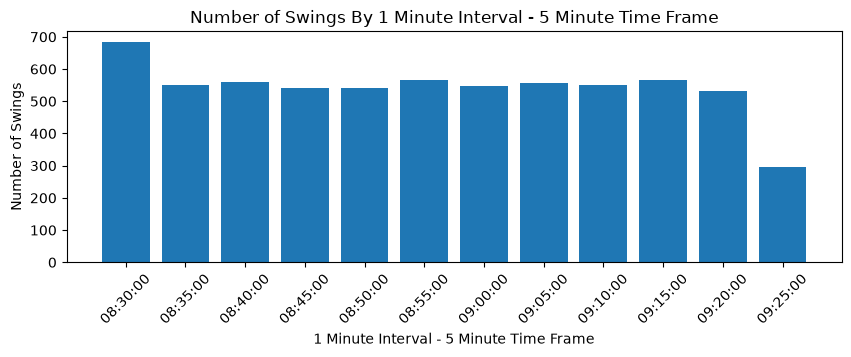

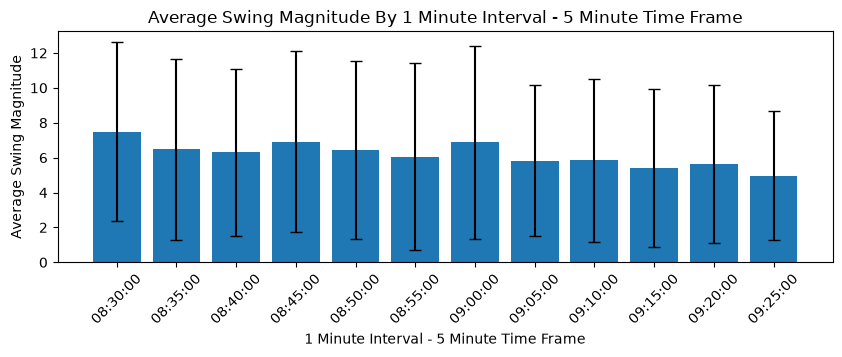

In [18]:
analyze_swings_by_time(df_swings,'5','1','profit_winsorized')

Analyze Swings

In [20]:
gb_profit = utils.descriptive_groupby(df_swings,'profit','profit')
gb_profit_win = utils.descriptive_groupby(df_swings,'profit_winsorized','profit_winsorized')

In [24]:
utils.descriptive_analysis(df_swings,'profit_winsorized')

count    6494.000000
mean        6.253931
std         4.946384
min         1.000000
25%         3.000000
50%         4.750000
75%         7.750000
max        28.035000
Name: profit_winsorized, dtype: float64

Median:  4.75
Std Dev:  4.946384014166112
IQR:  4.75


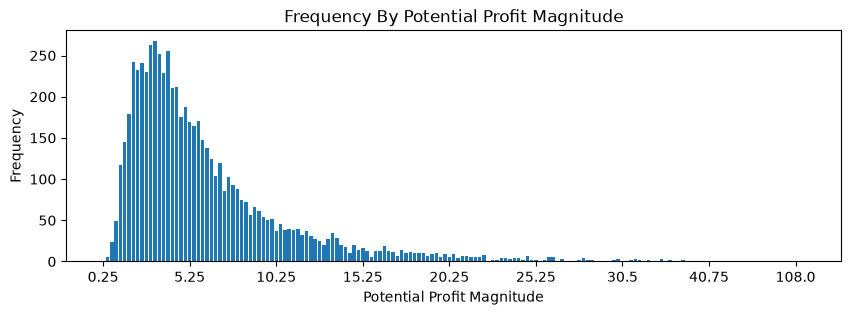

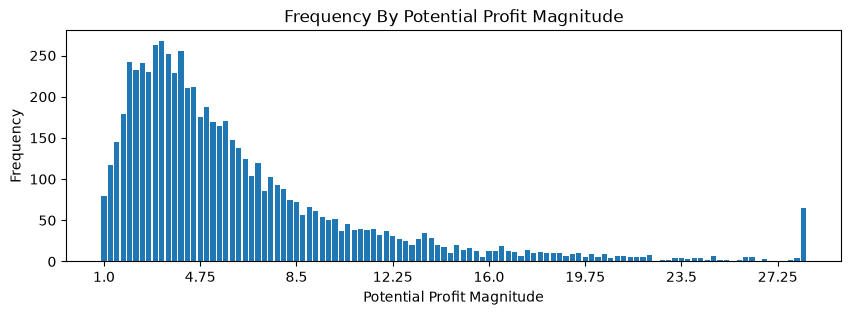

In [21]:
utils.bar_chart(gb_profit,'count','Potential Profit Magnitude','Frequency',angle=0,tickbin=10)
utils.bar_chart(gb_profit_win,'count','Potential Profit Magnitude','Frequency',angle=0,tickbin=10)